# NumPy Fundamentals

## 1. Introduction

**NumPy** (Numerical Python) is the foundation of numerical computing in Python. Before we dive into PyTorch tensors and neural networks, we need to master NumPy.

### What we'll learn:
- Creating and manipulating multi-dimensional arrays
- Indexing, slicing, and reshaping arrays
- Universal functions (ufuncs) for element-wise operations
- **Broadcasting rules** - a critical concept that carries over to PyTorch
- Random number generation for experiments

### Why this matters:
- PyTorch tensors behave very similarly to NumPy arrays
- Broadcasting is essential for efficient neural network computations
- Many ML libraries (pandas, scikit-learn) are built on NumPy
- Understanding NumPy makes you fluent in the "language" of scientific Python

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print(f"NumPy version: {np.__version__}")

NumPy version: 2.3.4


## 3. Array Creation

### Why NumPy arrays instead of Python lists?

Python lists are flexible but slow for numerical computations. NumPy arrays are:
- **Faster**: Operations are implemented in C
- **More memory efficient**: Fixed type, contiguous memory
- **Vectorized**: Operations work on entire arrays at once

### 3.1 From Python Lists

In [2]:
# Create a 1D array (vector)
arr_1d = np.array([1, 2, 3, 4, 5])
print("1D array:", arr_1d)
print("Shape:", arr_1d.shape)
print("Data type:", arr_1d.dtype)
print()

1D array: [1 2 3 4 5]
Shape: (5,)
Data type: int64



Display the output.

In [28]:
# Create a 2D array (matrix)
arr_2d = np.array([[1, 2, 3],
                    [4, 5, 6]])
print("2D array:")
print(arr_2d)
print("Shape:", arr_2d.shape)  # (rows, columns)
print("Number of dimensions:", arr_2d.ndim)

2D array:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Number of dimensions: 2


The **shape** tuple tells us the size of each dimension. `(2, 3)` means 2 rows and 3 columns.

### 3.2 Special Array Creation Functions

In [29]:
# Array of zeros - useful for initializing placeholders
zeros = np.zeros((3, 4))
print("Zeros:")
print(zeros)

Zeros:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Display the output.

In [30]:
# Array of ones - useful for biases or masks
ones = np.ones((2, 3))
print("Ones:")
print(ones)

Ones:
[[1. 1. 1.]
 [1. 1. 1.]]


Display the output.

In [31]:
# Identity matrix - critical for linear algebra
identity = np.eye(4)
print("Identity matrix:")
print(identity)

Identity matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


An **identity matrix** has ones on the diagonal and zeros elsewhere. Multiplying any matrix by the identity leaves it unchanged (like multiplying by 1).

In [32]:
# Range of values - like Python's range() but returns an array
range_arr = np.arange(0, 10, 2)  # start, stop, step
print("Range array:", range_arr)

Range array: [0 2 4 6 8]


Display the output.

In [33]:
# Evenly spaced values - useful for plotting
linspace_arr = np.linspace(0, 1, 5)  # start, stop, num_points
print("Linspace array:", linspace_arr)
print("Notice: includes both endpoints!")

Linspace array: [0.   0.25 0.5  0.75 1.  ]
Notice: includes both endpoints!


### 3.3 Reshaping Arrays

Often we need to change an array's shape without changing its data.

In [34]:
# Create a 1D array and reshape it
arr = np.arange(12)
print("Original:", arr)
print("Shape:", arr.shape)
print()

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)



Display the output.

In [35]:
# Reshape to 2D
arr_2d = arr.reshape(3, 4)
print("Reshaped to (3, 4):")
print(arr_2d)
print()

Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]



Display the output.

In [36]:
# Reshape to 3D
arr_3d = arr.reshape(2, 2, 3)
print("Reshaped to (2, 2, 3):")
print(arr_3d)
print("This creates 2 matrices of shape (2, 3)")

Reshaped to (2, 2, 3):
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
This creates 2 matrices of shape (2, 3)


**Key insight**: Reshaping doesn't copy data - it just changes how we view it. The total number of elements must stay the same!

In [37]:
# Use -1 to let NumPy infer one dimension
arr_auto = arr.reshape(4, -1)
print("Reshape with -1 (4, ?):", arr_auto.shape)
print(arr_auto)

Reshape with -1 (4, ?): (4, 3)
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


## 4. Array Indexing & Slicing

### 4.1 Basic Indexing

Like Python lists, but more powerful for multi-dimensional arrays.

In [38]:
# 1D indexing
arr = np.array([10, 20, 30, 40, 50])
print("Array:", arr)
print("First element:", arr[0])
print("Last element:", arr[-1])

Array: [10 20 30 40 50]
First element: 10
Last element: 50


Display the output.

In [39]:
# 2D indexing
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("Matrix:")
print(matrix)
print()
print("Element at row 1, col 2:", matrix[1, 2])  # 6
print("First row:", matrix[0])  # [1, 2, 3]
print("First column:", matrix[:, 0])  # [1, 4, 7]

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Element at row 1, col 2: 6
First row: [1 2 3]
First column: [1 4 7]


### 4.2 Slicing

Extract sub-arrays using the slice notation `start:stop:step`.

In [40]:
arr = np.arange(10)
print("Array:", arr)
print("arr[2:5]:", arr[2:5])  # indices 2, 3, 4
print("arr[:5]:", arr[:5])    # first 5 elements
print("arr[5:]:", arr[5:])    # from index 5 to end
print("arr[::2]:", arr[::2])  # every other element

Array: [0 1 2 3 4 5 6 7 8 9]
arr[2:5]: [2 3 4]
arr[:5]: [0 1 2 3 4]
arr[5:]: [5 6 7 8 9]
arr[::2]: [0 2 4 6 8]


Display the output.

In [41]:
# 2D slicing
matrix = np.arange(20).reshape(4, 5)
print("Matrix:")
print(matrix)
print()
print("Top-left 2x2 sub-matrix:")
print(matrix[:2, :2])
print()
print("Last 2 rows, middle 3 columns:")
print(matrix[-2:, 1:4])

Matrix:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

Top-left 2x2 sub-matrix:
[[0 1]
 [5 6]]

Last 2 rows, middle 3 columns:
[[11 12 13]
 [16 17 18]]


### 4.3 Boolean Indexing (Masking)

This is incredibly powerful - select elements based on conditions!

In [42]:
arr = np.array([1, 5, 3, 8, 2, 9, 4])
print("Array:", arr)

# Create a boolean mask
mask = arr > 4
print("Mask (arr > 4):", mask)

# Use mask to filter
filtered = arr[mask]
print("Filtered elements:", filtered)

Array: [1 5 3 8 2 9 4]
Mask (arr > 4): [False  True False  True False  True False]
Filtered elements: [5 8 9]


Display the output.

In [44]:
# Combine conditions
arr = np.arange(10)
mask = (arr > 2) & (arr < 7)  # Use & for 'and', | for 'or'
print("Array:", arr)
print("Mask:", mask)
print("Elements between 2 and 7:", arr[mask])

Array: [0 1 2 3 4 5 6 7 8 9]
Mask: [False False False  True  True  True  True False False False]
Elements between 2 and 7: [3 4 5 6]


**Boolean indexing is essential for data filtering and conditional operations in ML!**

### 4.4 Fancy Indexing

Select specific indices using arrays of integers.

In [45]:
arr = np.array([10, 20, 30, 40, 50])
indices = np.array([0, 2, 4])

print("Array:", arr)
print("Indices:", indices)
print("Selected elements:", arr[indices])

Array: [10 20 30 40 50]
Indices: [0 2 4]
Selected elements: [10 30 50]


Display the output.

In [46]:
# 2D fancy indexing
matrix = np.arange(12).reshape(3, 4)
print("Matrix:")
print(matrix)
print()

# Select specific rows
row_indices = [0, 2]
print("Rows 0 and 2:")
print(matrix[row_indices])

Matrix:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Rows 0 and 2:
[[ 0  1  2  3]
 [ 8  9 10 11]]


## 5. Array Operations & Universal Functions

### 5.1 Element-wise Arithmetic

Operations automatically apply to every element - this is **vectorization**!

In [47]:
arr = np.array([1, 2, 3, 4, 5])
print("Original:", arr)
print("arr + 10:", arr + 10)
print("arr * 2:", arr * 2)
print("arr ** 2:", arr ** 2)  # Square each element

Original: [1 2 3 4 5]
arr + 10: [11 12 13 14 15]
arr * 2: [ 2  4  6  8 10]
arr ** 2: [ 1  4  9 16 25]


Display the output.

In [48]:
# Operations between arrays (element-wise)
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("a:", a)
print("b:", b)
print("a + b:", a + b)
print("a * b:", a * b)  # NOT matrix multiplication!

a: [1 2 3]
b: [4 5 6]
a + b: [5 7 9]
a * b: [ 4 10 18]


**Important**: `*` is element-wise multiplication, not matrix multiplication. For matrix multiplication, use `@` or `np.dot()`.

### 5.2 Universal Functions (ufuncs)

NumPy provides optimized functions that operate element-wise on arrays.

In [49]:
arr = np.array([0, np.pi/2, np.pi])
print("Array:", arr)
print("sin(arr):", np.sin(arr))
print("cos(arr):", np.cos(arr))
print("exp(arr):", np.exp(arr))

Array: [0.         1.57079633 3.14159265]
sin(arr): [0.0000000e+00 1.0000000e+00 1.2246468e-16]
cos(arr): [ 1.000000e+00  6.123234e-17 -1.000000e+00]
exp(arr): [ 1.          4.81047738 23.14069263]


Display the output.

In [50]:
# Common ufuncs for ML
arr = np.array([-2, -1, 0, 1, 2])
print("Array:", arr)
print("abs(arr):", np.abs(arr))
print("sqrt(abs(arr)):", np.sqrt(np.abs(arr)))
print("log(abs(arr)+1):", np.log(np.abs(arr) + 1))

Array: [-2 -1  0  1  2]
abs(arr): [2 1 0 1 2]
sqrt(abs(arr)): [1.41421356 1.         0.         1.         1.41421356]
log(abs(arr)+1): [1.09861229 0.69314718 0.         0.69314718 1.09861229]


### 5.3 Aggregation Functions

Reduce arrays to summary statistics.

In [51]:
arr = np.array([1, 2, 3, 4, 5])
print("Array:", arr)
print("Sum:", np.sum(arr))
print("Mean:", np.mean(arr))
print("Std deviation:", np.std(arr))
print("Min:", np.min(arr))
print("Max:", np.max(arr))

Array: [1 2 3 4 5]
Sum: 15
Mean: 3.0
Std deviation: 1.4142135623730951
Min: 1
Max: 5


Display the output.

In [52]:
# Aggregation along specific axes
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print("Matrix:")
print(matrix)
print()
print("Sum of all elements:", np.sum(matrix))
print("Sum along axis 0 (columns):", np.sum(matrix, axis=0))
print("Sum along axis 1 (rows):", np.sum(matrix, axis=1))

Matrix:
[[1 2 3]
 [4 5 6]]

Sum of all elements: 21
Sum along axis 0 (columns): [5 7 9]
Sum along axis 1 (rows): [ 6 15]


**Axis confusion?** Think of `axis=0` as "collapsing rows" and `axis=1` as "collapsing columns".

### 5.4 Matrix Operations

Essential for neural networks!

In [53]:
# Matrix multiplication
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("Matrix A:")
print(A)
print()
print("Matrix B:")
print(B)
print()
print("A @ B (matrix multiplication):")
print(A @ B)
print()
print("A * B (element-wise):")
print(A * B)

Matrix A:
[[1 2]
 [3 4]]

Matrix B:
[[5 6]
 [7 8]]

A @ B (matrix multiplication):
[[19 22]
 [43 50]]

A * B (element-wise):
[[ 5 12]
 [21 32]]


Display the output.

In [54]:
# Transpose
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print("Original (2, 3):")
print(matrix)
print()
print("Transposed (3, 2):")
print(matrix.T)

Original (2, 3):
[[1 2 3]
 [4 5 6]]

Transposed (3, 2):
[[1 4]
 [2 5]
 [3 6]]


## 6. Broadcasting Rules

### This is THE most important concept for PyTorch!

**Broadcasting** allows NumPy to perform operations on arrays of different shapes by automatically expanding the smaller array.

### 6.1 Simple Broadcasting Example

In [55]:
# Adding a scalar to an array
arr = np.array([1, 2, 3])
scalar = 10

result = arr + scalar
print("Array:", arr)
print("Scalar:", scalar)
print("Result:", result)
print()
print("What happened? The scalar was 'broadcast' to match the array shape!")

Array: [1 2 3]
Scalar: 10
Result: [11 12 13]

What happened? The scalar was 'broadcast' to match the array shape!


### 6.2 Broadcasting with Different Shapes

**The Broadcasting Rules:**
1. If arrays have different number of dimensions, pad the smaller shape with ones on the left
2. If shapes differ in any dimension, the dimension with size 1 is stretched to match the other
3. If any dimension sizes differ and neither is 1, raise an error

In [65]:
# Example 1: Matrix + row vector
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
row = np.array([10, 20, 30])

print("Matrix shape:", matrix.shape)  # (3, 3)
print("Row shape:", row.shape)        # (3,)
print()
print("Matrix + row:")
print(matrix + row)
print()
print("The row [10, 20, 30] was broadcast to each row of the matrix!")

Matrix shape: (3, 3)
Row shape: (3,)

Matrix + row:
[[11 22 33]
 [14 25 36]
 [17 28 39]]

The row [10, 20, 30] was broadcast to each row of the matrix!


In [66]:
import numpy as np
a = np.array([1, 2, 3])
a.reshape(3, 1)

array([[1],
       [2],
       [3]])

Display the output.

In [67]:
# Example 2: Matrix + column vector
col = np.array([[10],
                [20],
                [30]])

print("Column shape:", col.shape)  # (3, 1)
print()
print("Matrix + column:")
print(matrix + col)
print()
print("The column was broadcast to each column of the matrix!")

Column shape: (3, 1)

Matrix + column:
[[11 12 13]
 [24 25 26]
 [37 38 39]]

The column was broadcast to each column of the matrix!


### 6.3 Visualizing Broadcasting

Let's visualize how broadcasting works with a concrete example.

In [69]:
# Create a grid for visualization
x = np.arange(5)  # shape (5,)
y = np.arange(4).reshape(4, 1)  # shape (4, 1)

print("x:", x, "shape:", x.shape)
print("y:", y.ravel(), "shape:", y.shape)
print()

# Broadcasting: (4, 1) + (5,) -> (4, 5)
grid = x + y
print("Grid (x + y) shape:", grid.shape)
print(grid)

x: [0 1 2 3 4] shape: (5,)
y: [0 1 2 3] shape: (4, 1)

Grid (x + y) shape: (4, 5)
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]]


In [70]:
x.shape

(5,)

In [71]:
y.shape

(4, 1)

Create a bar chart to compare values.

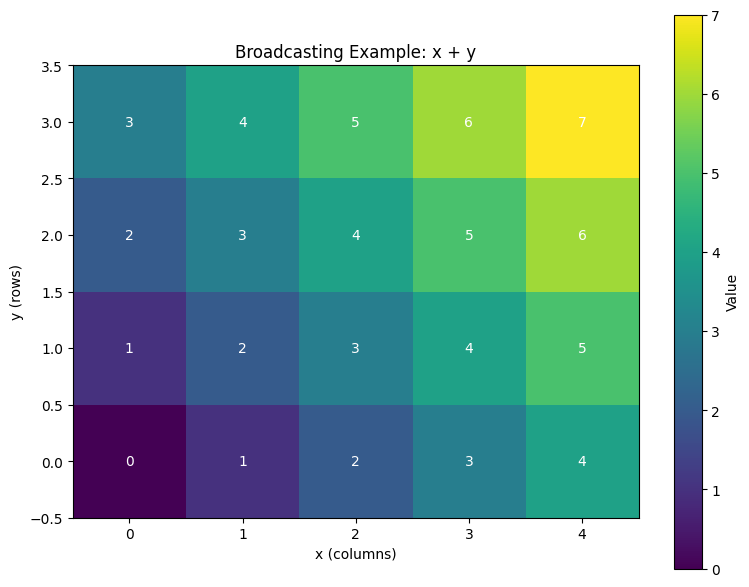

In [76]:
# Visualize the grid
plt.figure(figsize=(8, 6))
plt.imshow(grid, cmap='viridis', origin='lower')
plt.colorbar(label='Value')
plt.title('Broadcasting Example: x + y')
plt.xlabel('x (columns)')
plt.ylabel('y (rows)')

# Add text labels
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        plt.text(j, i, f'{grid[i, j]}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

### 6.4 Broadcasting Compatibility Check

In [77]:
def can_broadcast(shape1, shape2):
    """Check if two shapes are compatible for broadcasting."""
    # Pad shorter shape with 1s on the left
    ndim = max(len(shape1), len(shape2))
    shape1 = (1,) * (ndim - len(shape1)) + shape1
    shape2 = (1,) * (ndim - len(shape2)) + shape2
    
    # Check each dimension
    for s1, s2 in zip(shape1, shape2):
        if s1 != s2 and s1 != 1 and s2 != 1:
            return False
    return True

# Test cases
test_cases = [
    ((3, 4), (4,)),      # Compatible
    ((3, 4), (3, 1)),    # Compatible
    ((3, 4), (3, 4)),    # Compatible
    ((3, 4), (2, 4)),    # Incompatible
]

for shape1, shape2 in test_cases:
    result = can_broadcast(shape1, shape2)
    print(f"{shape1} + {shape2}: {'✓ Compatible' if result else '✗ Incompatible'}")

(3, 4) + (4,): ✓ Compatible
(3, 4) + (3, 1): ✓ Compatible
(3, 4) + (3, 4): ✓ Compatible
(3, 4) + (2, 4): ✗ Incompatible


### 6.5 Practical Broadcasting Example: Normalization

A common ML operation - standardizing each feature to zero mean and unit variance.

In [78]:
# Create sample data: 5 samples, 3 features
data = np.random.randn(5, 3) * 10 + 50
print("Original data:")
print(data)
print(f"Shape: {data.shape}")
print()

Original data:
[[54.96714153 48.61735699 56.47688538]
 [65.23029856 47.65846625 47.65863043]
 [65.79212816 57.67434729 45.30525614]
 [55.42560044 45.36582307 45.34270246]
 [52.41962272 30.86719755 32.75082167]]
Shape: (5, 3)



Display the output.

In [79]:
# Compute mean and std for each feature (column)
mean = data.mean(axis=0)
std = data.std(axis=0)

print("Mean per feature:", mean, f"shape: {mean.shape}")
print("Std per feature:", std, f"shape: {std.shape}")
print()

Mean per feature: [58.76695828 46.03663823 45.50685922] shape: (3,)
Std per feature: [5.60392234 8.66358622 7.58624648] shape: (3,)



Display the output.

In [80]:
# Normalize using broadcasting
normalized = (data - mean) / std

print("Normalized data:")
print(normalized)
print()
print("Verify: mean per feature ≈ 0:", normalized.mean(axis=0))
print("Verify: std per feature ≈ 1:", normalized.std(axis=0))

Normalized data:
[[-0.67806378  0.29788112  1.44604136]
 [ 1.15336007  0.18720054  0.28364109]
 [ 1.25361657  1.34329004 -0.02657481]
 [-0.59625342 -0.07742927 -0.02163873]
 [-1.13265945 -1.75094243 -1.6814689 ]]

Verify: mean per feature ≈ 0: [ 1.24344979e-15  8.88178420e-17 -1.77635684e-16]
Verify: std per feature ≈ 1: [1. 1. 1.]


**This is exactly how batch normalization works in neural networks!** Broadcasting makes this operation elegant and efficient.

## 7. Random Number Generation

### 7.1 Basic Random Functions

Essential for initialization, data augmentation, and stochastic algorithms.

In [81]:
# Uniform random numbers [0, 1)
uniform = np.random.rand(3, 4)
print("Uniform random [0, 1):")
print(uniform)

Uniform random [0, 1):
[[0.61185289 0.13949386 0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378 0.51423444]
 [0.59241457 0.04645041 0.60754485 0.17052412]]


Display the output.

In [82]:
# Random integers
integers = np.random.randint(0, 10, size=(3, 4))
print("Random integers [0, 10):")
print(integers)

Random integers [0, 10):
[[6 1 3 8]
 [1 9 8 9]
 [4 1 3 6]]


Display the output.

In [83]:
# Standard normal distribution (mean=0, std=1)
normal = np.random.randn(3, 4)
print("Standard normal:")
print(normal)

Standard normal:
[[-0.56228753  1.13022819  0.37311891 -0.38647295]
 [-1.15877024  0.56611283 -0.70445345 -1.3779393 ]
 [-0.35311665 -0.46146572  0.06665728 -0.17628566]]


Display the output.

In [84]:
# Normal distribution with custom mean and std
mean, std = 100, 15
custom_normal = np.random.normal(mean, std, size=(3, 4))
print(f"Normal (mean={mean}, std={std}):")
print(custom_normal)

Normal (mean=100, std=15):
[[118.01339158 110.47598412  97.42556747  86.3922013 ]
 [117.8293859  111.78298187 139.84015137 103.9522906 ]
 [124.62656674 106.9122445  101.28885207  77.35064077]]


### 7.2 Visualizing Distributions

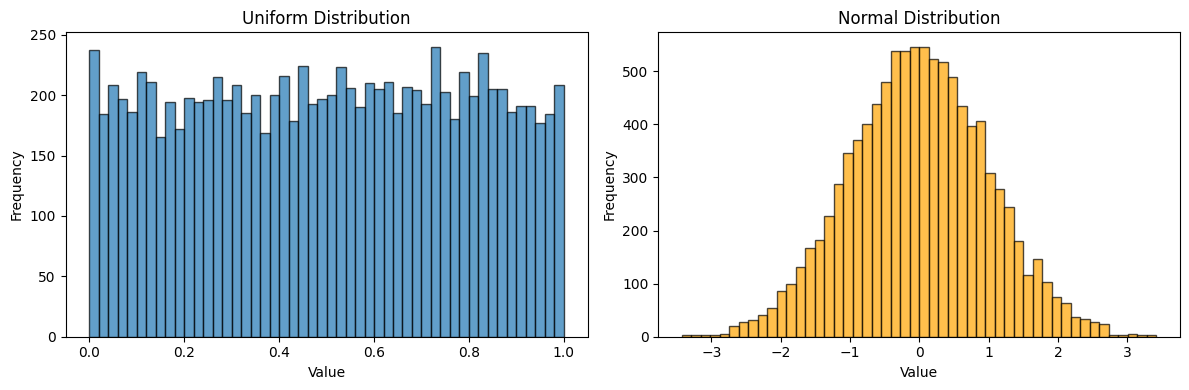

In [85]:
# Generate large samples
uniform_samples = np.random.rand(10000)
normal_samples = np.random.randn(10000)

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(uniform_samples, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Uniform Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(normal_samples, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Normal Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 7.3 Random Sampling & Shuffling

In [86]:
# Random choice from array
arr = np.array([10, 20, 30, 40, 50])
choice = np.random.choice(arr, size=3)
print("Random choice (with replacement):", choice)

Random choice (with replacement): [20 30 50]


Display the output.

In [87]:
# Random choice without replacement
choice_no_replace = np.random.choice(arr, size=3, replace=False)
print("Random choice (without replacement):", choice_no_replace)

Random choice (without replacement): [10 40 20]


Display the output.

In [88]:
# Shuffle an array in-place
arr = np.arange(10)
print("Original:", arr)
np.random.shuffle(arr)
print("Shuffled:", arr)

Original: [0 1 2 3 4 5 6 7 8 9]
Shuffled: [3 8 9 1 4 7 6 5 0 2]


### 7.4 Reproducibility with Seeds

Setting a seed ensures the same "random" numbers every time.

In [89]:
# Without seed - different each time
print("Run 1:", np.random.rand(3))
print("Run 2:", np.random.rand(3))
print()

Run 1: [0.35516619 0.27933102 0.67476304]
Run 2: [0.77854182 0.87395712 0.15532997]



Display the output.

In [90]:
# With seed - same each time
np.random.seed(42)
print("Run 1 (seed=42):", np.random.rand(3))

np.random.seed(42)
print("Run 2 (seed=42):", np.random.rand(3))
print()
print("Both runs produce identical results!")

Run 1 (seed=42): [0.37454012 0.95071431 0.73199394]
Run 2 (seed=42): [0.37454012 0.95071431 0.73199394]

Both runs produce identical results!


**Always set a seed in experiments** to make results reproducible!

## 8. Practical Example: Simulating a Neural Network Forward Pass

Let's use everything we've learned to simulate a simple neural network computation.

In [97]:
# Set seed for reproducibility
np.random.seed(42)

# Hyperparameters
batch_size = 4
input_dim = 5
hidden_dim = 3
output_dim = 2

Display the output.

In [98]:
# Create random input batch
X = np.random.randn(batch_size, input_dim)
print(f"Input X: shape {X.shape}")
print(X)

Input X: shape (4, 5)
[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]]


Display the output.

In [99]:
# Initialize weights (Xavier/Glorot initialization)
W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
b1 = np.zeros((1, hidden_dim))

print(f"W1: shape {W1.shape}")
print(f"b1: shape {b1.shape}")

W1: shape (5, 3)
b1: shape (1, 3)


Display the output.

In [100]:
# First layer: linear transformation
Z1 = X @ W1 + b1  # Broadcasting adds bias to each sample
print(f"Z1 (after linear): shape {Z1.shape}")
print(Z1)

Z1 (after linear): shape (4, 3)
[[-0.16543956 -0.29237966  1.42786456]
 [-2.11672487 -0.51222304 -0.45847247]
 [ 0.18165168  2.16601254 -3.28309897]
 [ 0.34224935  1.7939944  -2.01289196]]


Display the output.

In [101]:
# Activation function: ReLU
A1 = np.maximum(0, Z1)
print(f"A1 (after ReLU): shape {A1.shape}")
print(A1)

A1 (after ReLU): shape (4, 3)
[[0.         0.         1.42786456]
 [0.         0.         0.        ]
 [0.18165168 2.16601254 0.        ]
 [0.34224935 1.7939944  0.        ]]


Display the output.

In [102]:
# Second layer
W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
b2 = np.zeros((1, output_dim))

Z2 = A1 @ W2 + b2
print(f"Z2 (output logits): shape {Z2.shape}")
print(Z2)

Z2 (output logits): shape (4, 2)
[[ 0.22950999  0.8609387 ]
 [ 0.          0.        ]
 [-3.64683164 -2.31797436]
 [-3.21166496 -1.88714806]]


Display the output.

In [103]:
# Softmax for probabilities
exp_Z2 = np.exp(Z2 - np.max(Z2, axis=1, keepdims=True))  # Numerical stability
probabilities = exp_Z2 / np.sum(exp_Z2, axis=1, keepdims=True)

print(f"Probabilities: shape {probabilities.shape}")
print(probabilities)
print()
print("Each row sums to 1:", np.sum(probabilities, axis=1))

Probabilities: shape (4, 2)
[[0.34718665 0.65281335]
 [0.5        0.5       ]
 [0.20934845 0.79065155]
 [0.21006778 0.78993222]]

Each row sums to 1: [1. 1. 1. 1.]


**Notice how we used:**
- Matrix multiplication (`@`) for linear transformations
- Broadcasting for adding biases
- Universal functions (`np.maximum`, `np.exp`) for activations
- Axis-specific operations (`axis=1`) for normalization

All NumPy fundamentals in action!

## 9. Key Takeaways

### Core Concepts:
- **NumPy arrays** are the foundation of numerical computing in Python
- **Vectorization** makes operations fast and code clean
- **Broadcasting** enables operations on arrays of different shapes automatically
- **Universal functions** apply operations element-wise efficiently
- **Random number generation** with seeds ensures reproducibility

### Essential Skills:
1. Create arrays with various shapes and initializations
2. Index and slice multi-dimensional arrays
3. Use boolean and fancy indexing for filtering
4. Apply vectorized operations instead of loops
5. Understand broadcasting rules (critical for PyTorch!)
6. Use aggregation functions along specific axes

### Why This Matters:
- **PyTorch tensors** follow NumPy conventions closely
- Broadcasting is fundamental to neural network operations
- Efficient array manipulation is essential for ML pipelines
- NumPy is the lingua franca of scientific Python

### Next Steps:
Move on to **PyTorch tensors** - you'll see many familiar concepts, plus automatic differentiation!